<a href="https://colab.research.google.com/github/anooshk2606/-Urban-Heat-Island-Analysis-using-Land-Surface-Temperature-and-Built-up-Density/blob/main/Project2GIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd


In [ ]:
gdf = gpd.read_file("zip://gadm41_IND_2.json.zip")

In [ ]:
gdf.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IND.1.1_1,IND,India,IND.1_1,AndamanandNicobar,NA,NicobarIslands,NA,NA,District,District,NA,IN.AN.NI,"MULTIPOLYGON (((93.7899 6.852, 93.7909 6.851, ..."
1,IND.1.2_1,IND,India,IND.1_1,AndamanandNicobar,NA,NorthandMiddleAndaman,NA,NA,District,District,NA,IN.AN.NM,"MULTIPOLYGON (((92.8444 12.1497, 92.8461 12.15..."
2,IND.1.3_1,IND,India,IND.1_1,AndamanandNicobar,NA,SouthAndaman,NA,NA,District,District,NA,IN.AN.SA,"MULTIPOLYGON (((92.5211 10.8969, 92.53 10.8869..."
3,IND.2.1_1,IND,India,IND.2_1,AndhraPradesh,NA,Anantapur,"Anantpur,Ananthapur",NA,District,District,NA,IN.AD.AN,"MULTIPOLYGON (((77.846 13.9283, 77.8301 13.927..."
4,IND.2.2_1,IND,India,IND.2_1,AndhraPradesh,NA,Chittoor,Chitoor|Chittor,NA,District,District,NA,IN.AD.CH,"MULTIPOLYGON (((78.5455 12.7439, 78.5503 12.73..."


In [ ]:
Bangalore= gdf[gdf['NAME_2'] == 'Bangalore']

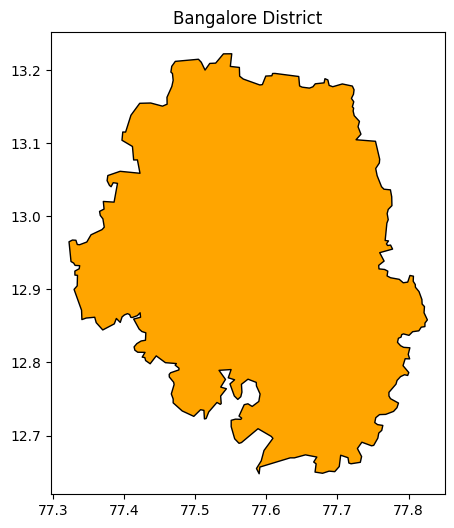

In [ ]:
Bangalore.plot(color="orange", edgecolor="black", figsize=(6,6))
plt.title("Bangalore District")
plt.show()

In [ ]:
gdf_utm = gdf.to_crs(epsg=32643)

In [ ]:
gdf_utm["area_sqkm"] = gdf_utm.geometry.area / 1000000

In [ ]:
gdf_utm[["NAME_2", "area_sqkm"]].head()

,NAME_2,area_sqkm
0,NicobarIslands,1921.112247
1,NorthandMiddleAndaman,3736.554943
2,SouthAndaman,2714.444683
3,Anantapur,19247.874733
4,Chittoor,15228.905502


In [ ]:
Bangalore.to_file("Bangalore_District.shp")

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
Bangalore_buffer = Bangalore.to_crs(epsg=32643)
Bangalore_buffer["geometry"] = Bangalore_buffer.buffer(10000)

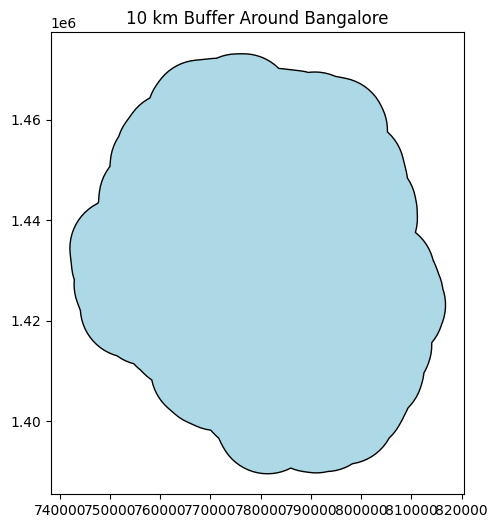

In [ ]:
Bangalore_buffer.plot(color="lightblue", edgecolor="black", figsize=(6,6))
plt.title("10 km Buffer Around Bangalore")
plt.show()

In [ ]:
Bangalore_buffer.to_file("Bangalore_Buffer_10km.shp")

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import ee
import geemap

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-17036')

In [ ]:
!pip install pycrs

  Preparing metadata (setup.py) ... done
  Created wheel for pycrs: filename=PyCRS-1.0.2-py3-none-any.whl size=32686 sha256=a7633cdb62b9762f3f0d5f593d963806b4b9a0f2152f8d18aef6eb0c9623d91a
  Stored in directory: /root/.cache/pip/wheels/b5/4a/72/1ba05f57ddf2cc80ad21a26512097762561d646ff3ff85f729
Successfully built pycrs


In [ ]:
aoi = geemap.shp_to_ee("/content/Bangalore_District.shp")

In [ ]:
Map = geemap.Map()

Map.centerObject(aoi,10)
Map.addLayer(aoi,{},'AOI')
Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
collection = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate('2023-01-01','2023-12-31')
    .filter(ee.Filter.lt('CLOUD_COVER',10))
)

image = collection.median().clip(aoi)

rgb = {
    'bands':['SR_B4','SR_B3','SR_B2'],
    'min':7000,
    'max':18000
}

Map.addLayer(image,rgb,'RGB')
Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
ndvi = image.normalizedDifference(['SR_B5','SR_B4']).rename('NDVI')

ndvi_vis = {
    'min':-1,
    'max':1,
    'palette':['brown','yellow','green']
}

Map.addLayer(ndvi,ndvi_vis,'NDVI')
Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
ndbi = image.normalizedDifference(['SR_B6','SR_B5']).rename('NDBI')

ndbi_vis = {
    'min':-0.5,
    'max':0.5,
    'palette':['green','white','red']
}

Map.addLayer(ndbi,ndbi_vis,'NDBI')
Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
lst = (
    image.select('ST_B10')
    .multiply(0.00341802)
    .add(149.0)
    .subtract(273.15)
    .rename('LST')
)

lst_vis = {
    'min':20,
    'max':45,
    'palette':['blue','cyan','green','yellow','orange','red']
}

Map.addLayer(lst,lst_vis,'LST')
Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
uhi = lst.gt(35)

Map.addLayer(
    uhi.updateMask(uhi),
    {'palette':['red']},
    'UHI'
)

Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
stats = lst.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=30,
    maxPixels=1e13
)

print("Average Temperature (°C)")
print(stats.getInfo())

Average Temperature (°C)
{'LST': 34.62029744916875}


In [ ]:
area_image = uhi.multiply(
    ee.Image.pixelArea()
)

area = area_image.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=30,
    maxPixels=1e13
)

heat_area = ee.Number(area.get('LST')).divide(1e6)

print("Heat Zone Area (sq.km)")
print(heat_area.getInfo())

Heat Zone Area (sq.km)
976.2177685038693


In [ ]:
sample = ndbi.addBands(lst).sample(
    region=aoi,
    scale=30,
    numPixels=5000,
    geometries=False
)

df = geemap.ee_to_df(sample)

df.head()

,LST,NDBI
0,34.100908,-0.052387
1,32.427787,-0.026878
2,36.712275,0.021373
3,36.655878,0.001129
4,35.196383,0.034603


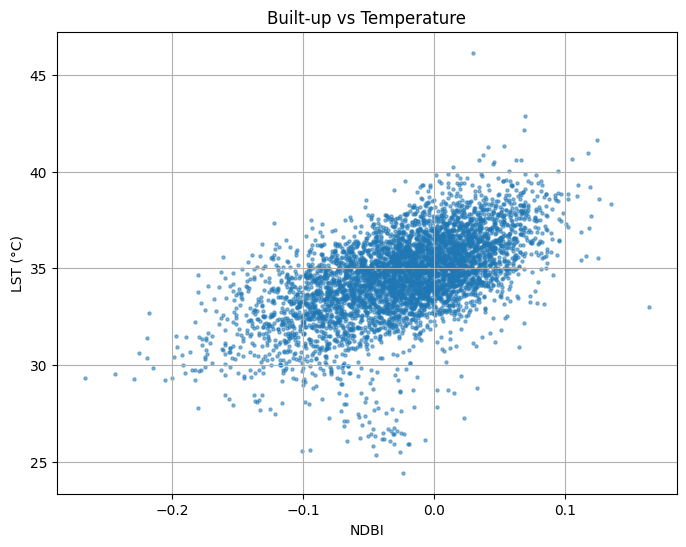

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["NDBI"],
    df["LST"],
    s=5,
    alpha=0.5
)

plt.xlabel("NDBI")
plt.ylabel("LST (°C)")
plt.title("Built-up vs Temperature")

plt.grid(True)

plt.show()

In [ ]:
corr = df["NDBI"].corr(df["LST"])

print("Correlation between NDBI and LST")

print(corr)

Correlation between NDBI and LST
0.5718567959497943


In [ ]:
Map = geemap.Map()

Map.centerObject(aoi,10)

Map.addLayer(lst,lst_vis,"LST")

Map.addLayer(aoi,{},'Boundary')

Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
Map = geemap.Map()

Map.centerObject(aoi,10)

Map.addLayer(ndvi,ndvi_vis,"NDVI")

Map.addLayer(aoi,{},'Boundary')

Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
Map = geemap.Map()

Map.centerObject(aoi,10)

Map.addLayer(ndbi,ndbi_vis,"NDBI")

Map.addLayer(aoi,{},'Boundary')

Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
Map = geemap.Map()

Map.centerObject(aoi,10)

Map.addLayer(
    uhi.updateMask(uhi),
    {'palette':['red']},
    "UHI"
)

Map.addLayer(aoi,{},'Boundary')

Map

Map(center=[12.942216649639322, 77.5868614593829], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
geemap.ee_export_image(
    lst,
    filename="LST_Bangalore.tif",
    scale=30,
    region=aoi.geometry(),
    file_per_band=False
)

geemap.ee_export_image(
    ndvi,
    filename="NDVI_Bangalore.tif",
    scale=30,
    region=aoi.geometry(),
    file_per_band=False
)

geemap.ee_export_image(
    ndbi,
    filename="NDBI_Bangalore.tif",
    scale=30,
    region=aoi.geometry(),
    file_per_band=False
)

geemap.ee_export_image(
    uhi,
    filename="UHI_Bangalore.tif",
    scale=30,
    region=aoi.geometry(),
    file_per_band=False
)

Generating URL ...
Please wait ...
Data downloaded to /content/LST_Bangalore.tif
Generating URL ...
Please wait ...
Data downloaded to /content/NDVI_Bangalore.tif
Generating URL ...
Please wait ...
Data downloaded to /content/NDBI_Bangalore.tif
Generating URL ...
Please wait ...
Data downloaded to /content/UHI_Bangalore.tif
